## Word Matching with a bipartite weighted graph

In this section, we'll show the matching of our reference sentence to the hypothesis transcript. The alignment is modelled as finding the min-cost max-flow in a bipartite network $G = (R' \cup H', E)$ with source $s$ and sink $t$.

### Dimension
Let $R = \{r_1, \dots, r_m\}$ be the set of reference words and $H = \{h_1, \dots, h_n\}$ be the set of hypothesis words. We define the augmented sets $R'$ and $H'$ with cardinality $N = m + n$:
- **Reference**: $R' = R \cup \{\epsilon_{r,1}, \dots, \epsilon_{r,n}\}$
- **Hypothesis**: $H' = H \cup \{\epsilon_{h,1}, \dots, \epsilon_{h,m}\}$
- **Dimension:** $|R'| = |H'| = N$ (Hall & Frobenius theorems satisfied)

### Cost functions (weights)
The cost $c_{ij}$ for matching an element $i \in R'$ with an element $j \in H'$ is defined as:

$$c_{ij} = \begin{cases} \text{cost}(r_i, h_j) & \text{if } r_i \in R, h_j \in H \\ \lambda & \text{if } (r_i \in R, h_j \notin H) \lor (r_i \notin R, h_j \in H) \\ 0 & \text{if } r_i \notin R, h_j \notin H \end{cases}$$
Where $\text{cost}(r_i, h_j)$ is either just the normalised Levenshtein distance **or** a combined lexical and positional score, 
and $\lambda$ represents the **penalty** for deletions or insertions.

### Optimisation
Minimise the total cost $Z$ of the flow $f_{ij}$ across all edges:
$$\text{Minimize} \quad Z = \sum_{(i,j) \in E} c_{ij} \cdot f_{ij}$$

#### Constraints
- capacity (one unit of flow)
	- $$f_{ij} \in \{0, 1\} \quad \forall (i, j) \in E$$
- every node $k$ (except source $s$ and sink $t$), incoming flow (i) equals outgoing flow (j):
	- $$\sum_{i:(i,k) \in E} f_{ik} = \sum_{j:(k,j) \in E} f_{kj} \quad \forall k \in V_{graph} \setminus \{s, t\}$$
- total flow must equal the augmented dimension $N$:
	- $$\sum_{j:(s,j) \in E} f_{sj} = N$$

## Imports

In [39]:
import sys
import importlib
sys.path.insert(0, "domain")
import pandas as pd

import bipartite_matching
import calculations
importlib.reload(bipartite_matching)
importlib.reload(calculations)

from bipartite_matching import build_bipartite_graph, solve_matching
from calculations import clean


In [ ]:
df_synthetic = pd.read_csv(
    "../transcripts/synthetic/synthetic-dialect-ignorant-transcript.tsv", sep="\t"
)

row = df_synthetic.iloc[6]
ref = clean(row["sentence"]).split()
hyp = clean(row["transcript"]).split()

print("Reference:", row["sentence"])
print("Hypothesis:", row["transcript"])

m = len(ref)
n = len(hyp)
N = m + n

G = build_bipartite_graph(
    ref,
    hyp,
    max_word_len=max(len(w) for w in ref),
    max_sent_len=m,
    is_levenshtein_normalization_global=False,
    alpha=0.7,
    lambda_=0.3,
)
matching = solve_matching(G)

# row 1: reference
ref_row = list(ref)

# row 2: matched hypothesis word per reference position, or ε
hypothesis_row = []
score_row = []
for i in range(m):
    ref_word = ref[i]
    hyp_node = matching[f"ref_{i}"]
    hyp_word = G.nodes[hyp_node]["word"]
    score = G.edges[f"ref_{i}", hyp_node]["score"]
    hypothesis_row.append(hyp_word)
    score_row.append(f"{score:.2f}")

# row 3: hypothesis in transcribed order
hyp_row = list(hyp)

# build df
df_alignment = pd.DataFrame(
    [ref_row, hypothesis_row, hyp_row, score_row],
    index=["Reference", "Hypothesis (matched)", "Hypothesis (original)", "Score"],
)
df_alignment.columns = range(1, max(n, m) + 1)
df_alignment

Source: undefiend v1 v2 v3 v4 AUTO v5
DIT: v1 v2 AUTO v3 v4 vx v5


,1,2,3,4,5,6,7
Source,undefiend,v1,v2,v3,v4,auto,v5
Hypothesis,ε,v1,v2,v3,v4,auto,v5
DIT,v1,v2,auto,v3,v4,vx,v5
Score,0.70,0.95,0.95,1.00,1.00,0.85,1.00


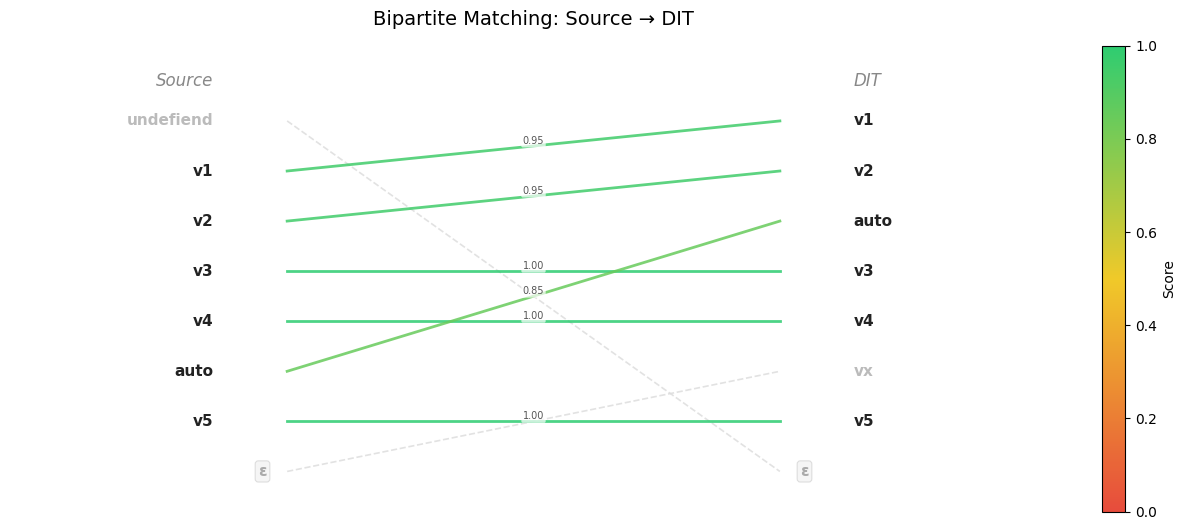

In [ ]:
import sys
sys.path.insert(0, "util")

import plot_helpers
importlib.reload(plot_helpers)

from plot_helpers import plot_bipartite_matching

plot_bipartite_matching(G, matching, ref, hyp)

## Params

$\lambda \leq 0.2$ : dialect specific words match to ε

=> **0.3** to match dialect specific words but still be able to use ε  

---

`is_levenshtein_normalization_global` :
- if true, lev similarity comparable but score range isn't fully used, all scores too high (above 0.9 => default to penalty)

=> explorative analysis shows that **false** works better

---

$\alpha = 1.0$ : No restriction, that word should be in neighbourhood

=> **0.8** seems to be a reasonable amt